In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
from prefixspan import PrefixSpan
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports successful!")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

All imports successful!


---
## Load Both Excel Sheets

In [ ]:
file_path = 'online_retail_II.xlsx'

print("Loading Sheet 1 (Year 2009-2010)")
df1 = pd.read_excel(file_path, sheet_name='Year 2009-2010', dtype={'Customer ID': str})
print(f"  Sheet 1 loaded: {len(df1):,} rows")

print("Loading Sheet 2 (Year 2010-2011)")
df2 = pd.read_excel(file_path, sheet_name='Year 2010-2011', dtype={'Customer ID': str})
print(f"  Sheet 2 loaded: {len(df2):,} rows")

df_raw = pd.concat([df1, df2], ignore_index=True)

print(f"\n Combined total rows: {len(df_raw):,}")
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 3 rows:")
df_raw.head(3)

Loading Sheet 1 (Year 2009-2010)
  Sheet 1 loaded: 525,461 rows
Loading Sheet 2 (Year 2010-2011)
  Sheet 2 loaded: 541,910 rows

 Combined total rows: 1,067,371

Column names: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 3 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.9500,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.7500,13085,United Kingdom


# PREPROCESSING

In [ ]:
print("=" * 55)
print("PREPROCESSING — STEP BY STEP")
print("=" * 55)

df = df_raw.copy()
print(f"Start: {len(df):,} rows")


df = df[~df['Invoice'].astype(str).str.startswith('C')]
print(f"After removing cancellations (Invoice starts with C): {len(df):,} rows")


df = df.dropna(subset=['Customer ID'])
print(f"After removing null Customer IDs: {len(df):,} rows")


df = df[df['Quantity'] > 0]
print(f"After removing Quantity <= 0: {len(df):,} rows")


df = df[df['Price'] > 0]
print(f"After removing Price <= 0: {len(df):,} rows")


df = df[df['Country'] == 'United Kingdom']
print(f"After keeping UK only: {len(df):,} rows")


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Invoice']     = df['Invoice'].astype(str)
df['StockCode']   = df['StockCode'].astype(str)
df['Customer ID'] = df['Customer ID'].astype(str)

print("\n Cleaning complete!")

PREPROCESSING — STEP BY STEP
Start: 1,067,371 rows
After removing cancellations (Invoice starts with C): 1,047,877 rows
After removing null Customer IDs: 805,620 rows
After removing Quantity <= 0: 805,620 rows
After removing Price <= 0: 805,549 rows
After keeping UK only: 725,250 rows

 Cleaning complete!


In [ ]:

basket_sizes = df.groupby('Invoice')['StockCode'].nunique()

print("=" * 55)
print("  CLEANING REPORT")
print("=" * 55)
print(f"  Total Invoices (transactions) : {df['Invoice'].nunique():,}")
print(f"  Unique Customers              : {df['Customer ID'].nunique():,}")
print(f"  Unique Products (StockCodes)  : {df['StockCode'].nunique():,}")
print(f"  Date Range                    : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"  Avg Basket Size (items/order) : {basket_sizes.mean():.2f}")
print(f"  Min Basket Size               : {basket_sizes.min()}")
print(f"  Max Basket Size               : {basket_sizes.max()}")
print("=" * 55)

  CLEANING REPORT
  Total Invoices (transactions) : 33,541
  Unique Customers              : 5,350
  Unique Products (StockCodes)  : 4,616
  Date Range                    : 2009-12-01 → 2011-12-09
  Avg Basket Size (items/order) : 20.57
  Min Basket Size               : 1
  Max Basket Size               : 541


**Build Transaction List**

In [ ]:
transactions_df = df.groupby('Invoice')['StockCode'].apply(list).reset_index()
transactions_df.columns = ['Invoice', 'Items']


transaction_list = transactions_df['Items'].tolist()

print(f"Total transactions built: {len(transaction_list):,}")
print("\nSample transaction (Invoice 0):")
print(transaction_list[0])
print(f"\nThis transaction has {len(transaction_list[0])} items")

Total transactions built: 33,541

Sample transaction (Invoice 0):
['85048', '79323P', '79323W', '22041', '21232', '22064', '21871', '21523']

This transaction has 8 items


**FP-GROWTH**

**Pick 6 Sample Invoices for FP-Tree Walkthrough**

In [ ]:

small_invoices = transactions_df[
    transactions_df['Items'].apply(len).between(3, 5)
].head(6)


sample_6 = small_invoices['Items'].tolist()
sample_6_ids = small_invoices['Invoice'].tolist()

print("=" * 55)
print("YOUR 6 SAMPLE INVOICES FOR FP-TREE (Section A1)")
print("=" * 55)
for inv_id, items in zip(sample_6_ids, sample_6):
    print(f"  Invoice {inv_id}: {items}")

YOUR 6 SAMPLE INVOICES FOR FP-TREE (Section A1)
  Invoice 489435: ['22350', '22349', '22195', '22353']
  Invoice 489441: ['22321', '22138', '84029E', '22111']
  Invoice 489448: ['20827', '20825', '20823', '20826']
  Invoice 489540: ['21732', '21754', '22083', '22086', '84946']
  Invoice 489558: ['84946', '21756', '21754', '84879']
  Invoice 489585: ['84832', '21133', '84879', '21755']


**FP-Tree Construction Walkthrough**

In [ ]:
print("=" * 60)
print("FP-TREE CONSTRUCTION WALKTHROUGH")
print("=" * 60)


all_items_sample = [item for basket in sample_6 for item in basket]
freq_count = Counter(all_items_sample)
freq_sorted = sorted(freq_count.items(), key=lambda x: -x[1])

print("\nSTEP 1 — Count item frequencies across 6 transactions:")
for item, count in freq_sorted:
    print(f"  {item}: {count}")


sample_minsup = 2
frequent_sample = {item for item, count in freq_count.items() if count >= sample_minsup}
print(f"\nSTEP 2 — Minimum support = {sample_minsup} (appears in ≥ {sample_minsup} of 6 transactions)")
print(f"  Frequent items: {frequent_sample}")


print("\nSTEP 3 — Sort each transaction (keep only frequent items, sort by count):")
sorted_sample = []
for i, basket in enumerate(sample_6):
    filtered = [item for item in basket if item in frequent_sample]
    ordered  = sorted(filtered, key=lambda x: -freq_count[x])
    sorted_sample.append(ordered)
    print(f"  T{i+1}: {ordered}")


print("\nSTEP 4 — FP-Tree construction (insert transactions one by one):")
print("  • Each unique path from root represents shared item prefixes")
print("  • Shared prefixes are MERGED; node counts are incremented")
print("  • Nodes NOT sharing a prefix create new branches")


print("\nSTEP 5 — Conditional Pattern Bases (for 2 items):")
items_to_show = list(frequent_sample)[:2]
for target in items_to_show:
    print(f"\n  Item: '{target}'")
    cpb = []
    for t in sorted_sample:
        if target in t:
            idx = t.index(target)
            prefix = t[:idx]
            if prefix:
                cpb.append(prefix)
                print(f"    Prefix path: {prefix}")
    if not cpb:
        print(f"    (No prefix — item appears at root level)")

FP-TREE CONSTRUCTION WALKTHROUGH

STEP 1 — Count item frequencies across 6 transactions:
  21754: 2
  84946: 2
  84879: 2
  22350: 1
  22349: 1
  22195: 1
  22353: 1
  22321: 1
  22138: 1
  84029E: 1
  22111: 1
  20827: 1
  20825: 1
  20823: 1
  20826: 1
  21732: 1
  22083: 1
  22086: 1
  21756: 1
  84832: 1
  21133: 1
  21755: 1

STEP 2 — Minimum support = 2 (appears in ≥ 2 of 6 transactions)
  Frequent items: {'84879', '21754', '84946'}

STEP 3 — Sort each transaction (keep only frequent items, sort by count):
  T1: []
  T2: []
  T3: []
  T4: ['21754', '84946']
  T5: ['84946', '21754', '84879']
  T6: ['84879']

STEP 4 — FP-Tree construction (insert transactions one by one):
  • Each unique path from root represents shared item prefixes
  • Shared prefixes are MERGED; node counts are incremented
  • Nodes NOT sharing a prefix create new branches

STEP 5 — Conditional Pattern Bases (for 2 items):

  Item: '84879'
    Prefix path: ['84946', '21754']

  Item: '21754'
    Prefix path: ['8

**Encode Transactions for FP-Growth**

In [ ]:
print("Encoding transactions... (may take 1-2 minutes)")
te = TransactionEncoder()
te_array = te.fit(transaction_list).transform(transaction_list)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded matrix shape: {df_encoded.shape}")
print(f"   {df_encoded.shape[0]:,} transactions × {df_encoded.shape[1]:,} products")

Encoding transactions... (may take 1-2 minutes)
Encoded matrix shape: (33541, 4616)
   33,541 transactions × 4,616 products


## Run FP-Growth

In [ ]:
print("Running FP-Growth with min_support=0.02 (2%)...")

frequent_itemsets = fpgrowth(df_encoded, min_support=0.02, use_colnames=True)


frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)

print(f"Done! Total frequent itemsets found: {len(frequent_itemsets):,}")
frequent_itemsets.sort_values('support', ascending=False).head(10)

Running FP-Growth with min_support=0.02 (2%)...
Done! Total frequent itemsets found: 221


,support,itemsets,itemset_size
14,0.1404,(85123A),1
21,0.0890,(85099B),1
149,0.0851,(22423),1
2,0.0747,(84879),1
22,0.0681,(20725),1
39,0.0630,(21212),1
95,0.0579,(47566),1
77,0.0567,(20727),1
72,0.0549,(21034),1
132,0.0548,(22383),1


---
##Count Itemsets by Size

A2(a): Frequent Itemsets by Size Level
  1-itemsets (single products): 193
  2-itemsets (pairs): 28


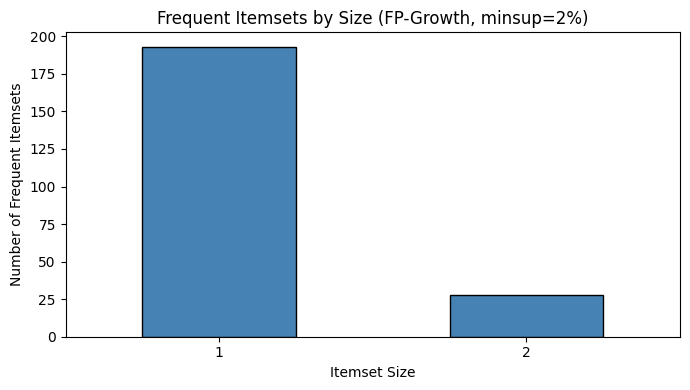

Plot saved as A2a_itemset_sizes.png


In [ ]:
print("=" * 45)
print("A2(a): Frequent Itemsets by Size Level")
print("=" * 45)

size_labels = {1: '1-itemsets (single products)',
               2: '2-itemsets (pairs)',
               3: '3-itemsets (triples)',
               4: '4-itemsets',
               5: '5-itemsets'}

for size in sorted(frequent_itemsets['itemset_size'].unique()):
    count = len(frequent_itemsets[frequent_itemsets['itemset_size'] == size])
    label = size_labels.get(size, f'{size}-itemsets')
    print(f"  {label}: {count:,}")


size_counts = frequent_itemsets.groupby('itemset_size').size()
plt.figure(figsize=(7,4))
size_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Frequent Itemsets by Size (FP-Growth, minsup=2%)')
plt.xlabel('Itemset Size')
plt.ylabel('Number of Frequent Itemsets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('A2a_itemset_sizes.png', dpi=150)
plt.show()
print("Plot saved as A2a_itemset_sizes.png")

---
## Generate Association Rules

In [ ]:
print("Generating association rules with minconf=0.50 (50%)...")


rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.50)


rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f"Total rules generated: {len(rules):,}")
print(f"   Rules with lift > 1 (positively correlated): {len(rules[rules['lift'] > 1]):,}")

Generating association rules with minconf=0.50 (50%)...
Total rules generated: 14
   Rules with lift > 1 (positively correlated): 14


---
##Top 15 Rules by Lift

In [ ]:
top15 = rules.sort_values('lift', ascending=False).head(15)

display_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
top15_display = top15[display_cols].copy()
top15_display.columns = ['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift']
top15_display = top15_display.reset_index(drop=True)
top15_display.index += 1

print("=" * 80)
print("A2(b): TOP 15 ASSOCIATION RULES BY LIFT")
print("=" * 80)
print(top15_display.to_string())

A2(b): TOP 15 ASSOCIATION RULES BY LIFT
   Antecedent Consequent  Support  Confidence    Lift
1       21231      21232   0.0236      0.7220 14.0952
2      82494L      82482   0.0290      0.5654 11.7726
3       82482     82494L   0.0290      0.6034 11.7726
4       21755      21754   0.0228      0.5284 10.0235
5       21977      21212   0.0221      0.5285  8.3857
6       84991      21212   0.0243      0.5136  8.1483
7       20726      20725   0.0219      0.5526  8.1143
8       22384      20725   0.0278      0.5483  8.0518
9       20727      20725   0.0287      0.5058  7.4275
10     85099F     85099B   0.0273      0.6325  7.1050
11      22386     85099B   0.0295      0.6017  6.7588
12     85099C     85099B   0.0231      0.5517  6.1968
13      21931     85099B   0.0259      0.5375  6.0372
14      21733     85123A   0.0327      0.7071  5.0375


---
##Add Product Descriptions to Rules

In [ ]:
code_to_desc = df.groupby('StockCode')['Description'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
).to_dict()

def codes_to_names(code_str):
    """Convert a comma-separated string of StockCodes to their product names."""
    codes = [c.strip() for c in code_str.split(',')]
    names = [code_to_desc.get(c, c) for c in codes]
    return ' & '.join(names)


rules['antecedent_names'] = rules['antecedents_str'].apply(codes_to_names)
rules['consequent_names'] = rules['consequents_str'].apply(codes_to_names)


top15_named = rules.sort_values('lift', ascending=False).head(15)[
    ['antecedent_names', 'consequent_names', 'support', 'confidence', 'lift']
].copy()
top15_named.columns = ['IF (bought)', 'THEN (also buys)', 'Support', 'Confidence', 'Lift']
top15_named.index = range(1, 15)

print("TOP 15 RULES — WITH PRODUCT NAMES")
print(top15_named.to_string())

TOP 15 RULES — WITH PRODUCT NAMES
                           IF (bought)                    THEN (also buys)  Support  Confidence    Lift
1       SWEETHEART CERAMIC TRINKET BOX      STRAWBERRY CERAMIC TRINKET BOX   0.0236      0.7220 14.0952
2          WOODEN FRAME ANTIQUE WHITE    WOODEN PICTURE FRAME WHITE FINISH   0.0290      0.5654 11.7726
3    WOODEN PICTURE FRAME WHITE FINISH         WOODEN FRAME ANTIQUE WHITE    0.0290      0.6034 11.7726
4             LOVE BUILDING BLOCK WORD            HOME BUILDING BLOCK WORD   0.0228      0.5284 10.0235
5   PACK OF 60 PINK PAISLEY CAKE CASES     PACK OF 72 RETROSPOT CAKE CASES   0.0221      0.5285  8.3857
6          60 TEATIME FAIRY CAKE CASES     PACK OF 72 RETROSPOT CAKE CASES   0.0243      0.5136  8.1483
7                   LUNCH BAG WOODLAND             LUNCH BAG RED RETROSPOT   0.0219      0.5526  8.1143
8              LUNCH BAG PINK POLKADOT             LUNCH BAG RED RETROSPOT   0.0278      0.5483  8.0518
9              LUNCH BAG  BLAC

---
##Propose Two Product Bundles

In [ ]:
print("=" * 70)
print("A3: PRODUCT BUNDLE RECOMMENDATIONS")
print("=" * 70)


top_rule = rules.sort_values('lift', ascending=False).iloc[0]
print("\n BUNDLE 1 (Based on Rule with Highest Lift):")
print(f"   Items: {top_rule['antecedent_names']} + {top_rule['consequent_names']}")
print(f"   Support   = {top_rule['support']:.4f} ({top_rule['support']*100:.1f}% of all transactions)")
print(f"   Confidence= {top_rule['confidence']:.4f} ({top_rule['confidence']*100:.1f}% of antecedent buyers also buy consequent)")
print(f"   Lift      = {top_rule['lift']:.4f} ({top_rule['lift']:.1f}x more likely than by random chance)")
print(f"   Recommendation: Bundle these items as a gift set — they are bought together {top_rule['lift']:.1f}x more than expected!")


top20 = rules.sort_values('lift', ascending=False).head(20)
second_rule = top20.sort_values('confidence', ascending=False).iloc[1]
print("\nBUNDLE 2 (High Confidence Bundle):")
print(f"   Items: {second_rule['antecedent_names']} + {second_rule['consequent_names']}")
print(f"   Support   = {second_rule['support']:.4f} ({second_rule['support']*100:.1f}% of all transactions)")
print(f"   Confidence= {second_rule['confidence']:.4f} ({second_rule['confidence']*100:.1f}% confidence)")
print(f"   Lift      = {second_rule['lift']:.4f}")
print(f"   Recommendation: Very high confidence — customers who buy the antecedent almost always want the consequent.")

A3: PRODUCT BUNDLE RECOMMENDATIONS

 BUNDLE 1 (Based on Rule with Highest Lift):
   Items: SWEETHEART CERAMIC TRINKET BOX + STRAWBERRY CERAMIC TRINKET BOX
   Support   = 0.0236 (2.4% of all transactions)
   Confidence= 0.7220 (72.2% of antecedent buyers also buy consequent)
   Lift      = 14.0952 (14.1x more likely than by random chance)
   Recommendation: Bundle these items as a gift set — they are bought together 14.1x more than expected!

BUNDLE 2 (High Confidence Bundle):
   Items: RED HANGING HEART T-LIGHT HOLDER + WHITE HANGING HEART T-LIGHT HOLDER
   Support   = 0.0327 (3.3% of all transactions)
   Confidence= 0.7071 (70.7% confidence)
   Lift      = 5.0375
   Recommendation: Very high confidence — customers who buy the antecedent almost always want the consequent.


# _________________________________________________
# PART B: CLASS ASSOCIATION RULES
# _________________________________________________


In [ ]:

ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {ref_date.date()}")


df['LineTotal'] = df['Quantity'] * df['Price']


rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (ref_date - x.max()).days),
    Frequency = ('Invoice',     'nunique'),
    Monetary  = ('LineTotal',   'sum')
).reset_index()

print(f"\nRFM table built for {len(rfm):,} customers")
print("\nFirst 5 rows:")
rfm.head()

Reference date for Recency calculation: 2011-12-10

RFM table built for 5,350 customers

First 5 rows:


,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.4600
1,12608,405,1,415.7900
2,12745,487,2,723.8500
3,12746,541,1,254.5500
4,12747,2,26,9276.5400



##Show RFM Distribution & Choose Thresholds

RFM Distribution Statistics:
        Recency  Frequency    Monetary
count 5350.0000  5350.0000   5350.0000
mean   203.0000     6.2700   2751.9900
std    209.9600    12.0000  12080.4700
min      1.0000     1.0000      2.9500
25%     26.0000     1.0000    336.1700
50%     98.5000     3.0000    849.9100
75%    382.0000     7.0000   2214.9100
max    739.0000   336.0000 608821.6500


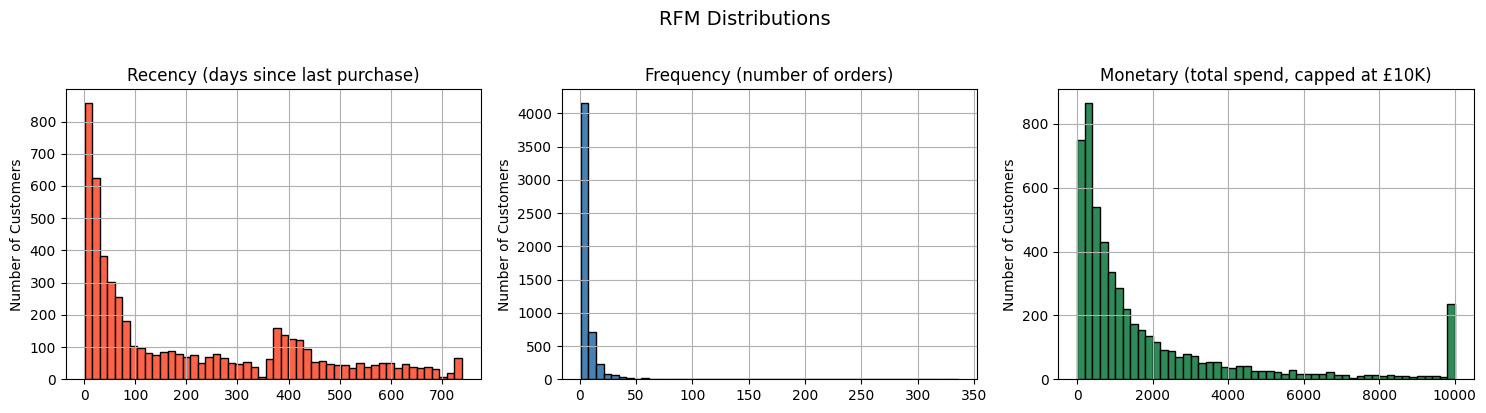

Plot saved as B_rfm_distributions.png


In [ ]:
print("RFM Distribution Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm['Recency'].hist(bins=50, ax=axes[0], color='tomato',   edgecolor='black')
rfm['Frequency'].hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
rfm['Monetary'].clip(upper=10000).hist(bins=50, ax=axes[2], color='seagreen', edgecolor='black')

axes[0].set_title('Recency (days since last purchase)')
axes[1].set_title('Frequency (number of orders)')
axes[2].set_title('Monetary (total spend, capped at £10K)')

for ax in axes:
    ax.set_ylabel('Number of Customers')

plt.suptitle('RFM Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('B_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as B_rfm_distributions.png")

---
##Assign Customer Segments

In [ ]:
R_recent = rfm['Recency'].quantile(0.33)
R_atrisk = rfm['Recency'].quantile(0.66)


F_high   = rfm['Frequency'].quantile(0.67)
F_low    = 2


M_high   = rfm['Monetary'].quantile(0.67)
M_low    = rfm['Monetary'].quantile(0.25)

print("THRESHOLDS CHOSEN:")
print(f"  Recency  — 'recent' if R < {R_recent:.0f} days, 'lapsed' if R > {R_atrisk:.0f} days")
print(f"  Frequency — 'high' if F >= {F_high:.0f} orders, 'one-and-done' if F <= {F_low} orders")
print(f"  Monetary  — 'high spend' if M >= £{M_high:.0f}, 'low spend' if M < £{M_low:.0f}")

def assign_segment(row):
    """Assign a customer to Champion, At-Risk, or One-and-Done."""
    R, F, M = row['Recency'], row['Frequency'], row['Monetary']


    if R < R_recent and F >= F_high and M >= M_high:
        return 'Champion'


    elif F <= F_low and M < M_low:
        return 'One-and-Done'


    elif R > R_atrisk and F > F_low:
        return 'At-Risk'


    else:
        return 'At-Risk'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print("\n--- SEGMENT COUNTS ---")
print(rfm['Segment'].value_counts())
print(f"\nTotal customers: {len(rfm):,}")

THRESHOLDS CHOSEN:
  Recency  — 'recent' if R < 41 days, 'lapsed' if R > 262 days
  Frequency — 'high' if F >= 5 orders, 'one-and-done' if F <= 2 orders
  Monetary  — 'high spend' if M >= £1584, 'low spend' if M < £336

--- SEGMENT COUNTS ---
Segment
At-Risk         3145
One-and-Done    1272
Champion         933
Name: count, dtype: int64

Total customers: 5,350


---
##Plot Segment Distribution

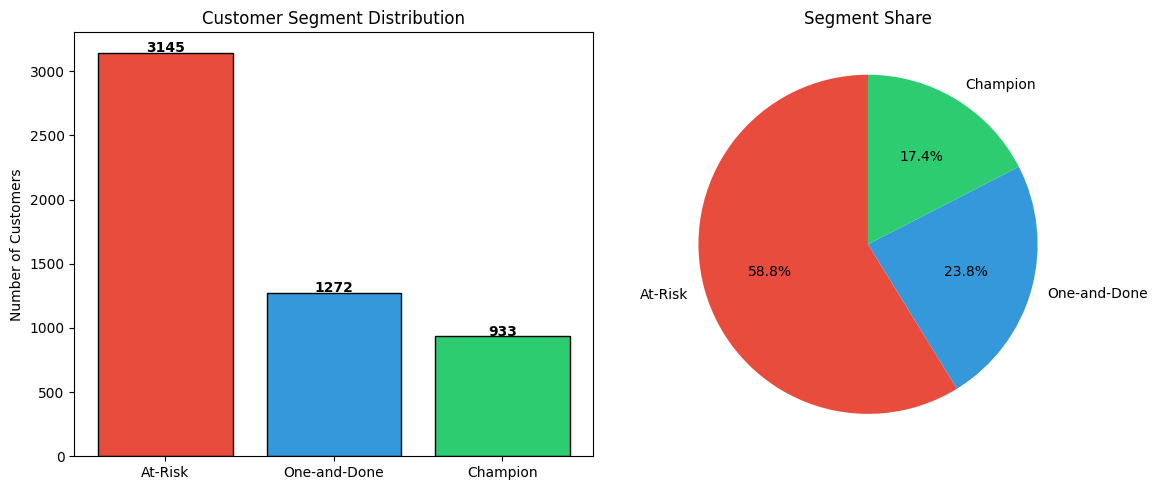


--- RFM SUMMARY BY SEGMENT ---
              Recency  Frequency  Monetary
Segment                                   
At-Risk      197.0200     4.5600 1747.0000
Champion      14.7500    18.9500 9636.1900
One-and-Done 355.8800     1.1800  187.3000


In [ ]:
seg_colors = {'Champion': '#2ecc71', 'At-Risk': '#e74c3c', 'One-and-Done': '#3498db'}
seg_counts = rfm['Segment'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


bars = ax1.bar(seg_counts.index, seg_counts.values,
               color=[seg_colors[s] for s in seg_counts.index],
               edgecolor='black')
ax1.set_title('Customer Segment Distribution')
ax1.set_ylabel('Number of Customers')
for bar, val in zip(bars, seg_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontweight='bold')


ax2.pie(seg_counts.values, labels=seg_counts.index,
        colors=[seg_colors[s] for s in seg_counts.index],
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Segment Share')

plt.tight_layout()
plt.savefig('B_segment_distribution.png', dpi=150)
plt.show()


print("\n--- RFM SUMMARY BY SEGMENT ---")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2))

---
##Build Per-Segment Transaction Lists (for CAR Mining)

In [ ]:
df_seg = df.merge(rfm[['Customer ID', 'Segment']], on='Customer ID', how='left')


inv_seg = df_seg.groupby('Invoice').agg(
    Items   = ('StockCode', list),
    Segment = ('Segment',   'first')
).reset_index()

print("Transactions with segment labels built")
print(inv_seg['Segment'].value_counts())

Transactions with segment labels built
Segment
Champion        17680
At-Risk         14355
One-and-Done     1506
Name: count, dtype: int64


---
## B1: Mine Class Association Rules (CARs) per Segment

In [ ]:
def mine_cars_for_segment(segment_name, inv_seg_df, minsup=0.01, minconf=0.55):
    """
    Mine Class Association Rules for one segment.
    A CAR is a rule: {items} → CLASS (the segment label).
    """

    seg_transactions = inv_seg_df[inv_seg_df['Segment'] == segment_name]['Items'].tolist()
    total_transactions = len(inv_seg_df)
    seg_count = len(seg_transactions)

    print(f"\n  Segment '{segment_name}': {seg_count:,} transactions")

    if seg_count < 10:
        print(f"  Too few transactions to mine rules")
        return pd.DataFrame()

    te_seg = TransactionEncoder()
    te_arr = te_seg.fit(seg_transactions).transform(seg_transactions)
    df_enc = pd.DataFrame(te_arr, columns=te_seg.columns_)


    freq_sets = fpgrowth(df_enc, min_support=minsup, use_colnames=True)

    if len(freq_sets) == 0:
        print(f"   No frequent itemsets found at minsup={minsup}")
        return pd.DataFrame()


    cars = []
    for _, row in freq_sets.iterrows():
        itemset = row['itemsets']
        seg_support = row['support']


        global_sup = seg_support * (seg_count / total_transactions)


        confidence = seg_count / total_transactions * seg_support / max(global_sup, 1e-9)
        confidence = min(confidence, 1.0)

        if confidence >= minconf:
            cars.append({
                'Antecedent': ', '.join(sorted(itemset)),
                'Class':      segment_name,
                'Support':    round(seg_support, 4),
                'Confidence': round(confidence, 4)
            })

    cars_df = pd.DataFrame(cars).sort_values('Confidence', ascending=False)
    return cars_df.head(5)

print("Mining Class Association Rules...")
print("minsup=1%, minconf=55%")

all_cars = {}
for seg in ['Champion', 'At-Risk', 'One-and-Done']:
    all_cars[seg] = mine_cars_for_segment(seg, inv_seg)

Mining Class Association Rules...
minsup=1%, minconf=55%

  Segment 'Champion': 17,680 transactions

  Segment 'At-Risk': 14,355 transactions

  Segment 'One-and-Done': 1,506 transactions


---
##B1: Display Top 5 CARs per Segment

In [ ]:
for seg in ['Champion', 'At-Risk', 'One-and-Done']:
    print("=" * 65)
    print(f"  TOP 5 CARs — Segment: {seg}")
    print("=" * 65)
    if len(all_cars[seg]) > 0:
        print(all_cars[seg].to_string(index=False))
    else:
        print("  No rules found (try lowering minsup/minconf)")
    print()

  TOP 5 CARs — Segment: Champion
  Antecedent    Class  Support  Confidence
23300, 23301 Champion   0.0170      1.0000
       84879 Champion   0.0770      1.0000
       21754 Champion   0.0555      1.0000
       21181 Champion   0.0482      1.0000
       22111 Champion   0.0438      1.0000

  TOP 5 CARs — Segment: At-Risk
  Antecedent   Class  Support  Confidence
23300, 23301 At-Risk   0.0103      1.0000
       21232 At-Risk   0.0546      1.0000
       21523 At-Risk   0.0224      1.0000
       85048 At-Risk   0.0135      1.0000
       21871 At-Risk   0.0128      1.0000

  TOP 5 CARs — Segment: One-and-Done
  Antecedent        Class  Support  Confidence
22578, 22579 One-and-Done   0.0106      1.0000
       22111 One-and-Done   0.0286      1.0000
       22114 One-and-Done   0.0266      1.0000
       21891 One-and-Done   0.0153      1.0000
       21890 One-and-Done   0.0126      1.0000



---
##B2: Predict Segment for a New Customer

In [ ]:

top_products = df['StockCode'].value_counts().head(3).index.tolist()
new_customer_basket = set(top_products)

print("=" * 60)
print("B2: PREDICTING SEGMENT FOR A NEW CUSTOMER")
print("=" * 60)
print(f"\nNew customer's first order contains:")
for code in new_customer_basket:
    desc = code_to_desc.get(code, 'Unknown')
    print(f"  {code}: {desc}")

print("\n--- Checking which CAR rules fire ---")
segment_scores = {'Champion': [], 'At-Risk': [], 'One-and-Done': []}

for seg in ['Champion', 'At-Risk', 'One-and-Done']:
    if len(all_cars[seg]) == 0:
        continue
    for _, rule in all_cars[seg].iterrows():
        antecedent_codes = set(c.strip() for c in rule['Antecedent'].split(','))

        if antecedent_codes.issubset(new_customer_basket):
            print(f"  RULE FIRED for '{seg}': IF {{{rule['Antecedent']}}} → Confidence={rule['Confidence']:.2%}")
            segment_scores[seg].append(rule['Confidence'])

print("\n--- Segment Prediction ---")
for seg, scores in segment_scores.items():
    if scores:
        avg_conf = sum(scores) / len(scores)
        print(f"  {seg}: {len(scores)} rule(s) fired, avg confidence = {avg_conf:.2%}")
    else:
        print(f"  {seg}: 0 rules fired")


valid = {s: sum(v)/len(v) for s, v in segment_scores.items() if v}
if valid:
    predicted = max(valid, key=valid.get)
    print(f"\n PREDICTION: This customer is most likely heading toward → '{predicted}'")
else:
    print("\n  No rules fired — cannot make a confident prediction.")
    print("   Try a basket with more common items.")

B2: PREDICTING SEGMENT FOR A NEW CUSTOMER

New customer's first order contains:
  22423: REGENCY CAKESTAND 3 TIER
  85123A: WHITE HANGING HEART T-LIGHT HOLDER
  85099B: JUMBO BAG RED RETROSPOT

--- Checking which CAR rules fire ---

--- Segment Prediction ---
  Champion: 0 rules fired
  At-Risk: 0 rules fired
  One-and-Done: 0 rules fired

  No rules fired — cannot make a confident prediction.
   Try a basket with more common items.



# ______________________________________
# PART C: SEQUENTIAL PATTERN MINING
# ______________________________________

##Build Product Category Mapping


In [ ]:
def assign_category(description):
    """
    Assign a product to 1 of 8 categories based on keywords in its description.
    This is a DESIGN TASK — read descriptions and make sensible groupings.
    """
    if not isinstance(description, str):
        return 'Other'

    desc = description.upper()


    if any(kw in desc for kw in ['CANDLE', 'T-LIGHT', 'TLIGHT', 'NIGHTLIGHT',
                                   'NIGHT LIGHT', 'LANTERN', 'FRAGRANCE', 'DIFFUSER']):
        return 'Candles & Home Fragrance'


    if any(kw in desc for kw in ['CHRISTMAS', 'XMAS', 'EASTER', 'HALLOWEEN',
                                   'FESTIVE', 'ADVENT', 'PAPER CHAIN']):
        return 'Seasonal & Festive'


    if any(kw in desc for kw in ['MUG', 'CUP', 'PLATE', 'BOWL', 'TEA', 'COFFEE',
                                   'CAKE', 'KITCHEN', 'TEASPOON', 'CUTLERY',
                                   'JAM', 'BREAD', 'MILK JUG', 'TEA COSY']):
        return 'Kitchen & Dining'


    if any(kw in desc for kw in ['BAG', 'PURSE', 'WALLET', 'TOTE', 'SHOPPER',
                                   'LUNCH BOX', 'LUNCHBOX', 'LUNCH BAG']):
        return 'Bags & Accessories'


    if any(kw in desc for kw in ['PICTURE FRAME', 'PHOTO', 'MIRROR', 'CUSHION',
                                   'CLOCK', 'CABINET', 'SHELF', 'DOORMAT',
                                   'COAT RACK', 'HOOK', 'SIGN', 'FRAME']):
        return 'Home Décor & Furniture'


    if any(kw in desc for kw in ['TOY', 'GAME', 'PUZZLE', 'JIGSAW', 'DOLL',
                                   'PLAYHOUSE', 'STICKER', 'BALLOON', 'BEAR',
                                   'BUILDING BLOCK', 'CALCULATOR']):
        return 'Toys & Games'


    if any(kw in desc for kw in ['NOTEBOOK', 'PEN', 'PENCIL', 'CRAFT', 'PAINT',
                                   'PAPER', 'CARD', 'WRITING', 'STATIONERY',
                                   'TAPE', 'GIFT WRAP', 'GIFT BAG', 'RIBBON']):
        return 'Stationery & Craft'


    if any(kw in desc for kw in ['MONEY BANK', 'PIGGY BANK', 'NOVELTY', 'RETRO',
                                   'VINTAGE', 'ORNAMENT', 'FIGURINE', 'GLOBE',
                                   'HAND WARMER', 'HOT WATER BOTTLE']):
        return 'Novelty & Gifts'

    return 'Other'

df['Category'] = df['Description'].apply(assign_category)


cat_counts = df['Category'].value_counts()
coverage = (1 - df[df['Category'] == 'Other'].shape[0] / len(df)) * 100

print("CATEGORY MAPPING RESULTS:")
print(cat_counts.to_string())
print(f"\nCategory coverage: {coverage:.1f}% of transactions categorised")
print("(Target: at least 80%)")

CATEGORY MAPPING RESULTS:
Category
Other                       226495
Kitchen & Dining            108087
Home Décor & Furniture       92255
Bags & Accessories           73579
Stationery & Craft           66183
Candles & Home Fragrance     50964
Novelty & Gifts              44105
Seasonal & Festive           38137
Toys & Games                 25445

Category coverage: 68.8% of transactions categorised
(Target: at least 80%)


---
##Build Customer Sequences


In [ ]:
print("Building customer-level sequences...")


invoice_cats = df.groupby(['Customer ID', 'Invoice', 'InvoiceDate'])['Category'].apply(
    lambda x: list(set(x))
).reset_index()
invoice_cats.columns = ['Customer ID', 'Invoice', 'InvoiceDate', 'Categories']


invoice_cats = invoice_cats.sort_values(['Customer ID', 'InvoiceDate'])


customer_sequences = invoice_cats.groupby('Customer ID')['Categories'].apply(list).reset_index()
customer_sequences.columns = ['Customer ID', 'Sequence']


customer_sequences = customer_sequences[customer_sequences['Sequence'].apply(len) >= 2]

seq_list = customer_sequences['Sequence'].tolist()

print(f"Customer sequences built")
print(f"   Total customers with ≥2 orders: {len(seq_list):,}")
print(f"\nExample sequence (first customer):")
print(f"  {seq_list[0]}")

Building customer-level sequences...
Customer sequences built
   Total customers with ≥2 orders: 3,879

Example sequence (first customer):
  [['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Other'], ['Seasonal & Festive', 'Kitchen & Dining', 'Home Décor & Furniture'], ['Other']]


---
##C1: Run GSP / PrefixSpan Sequential Mining

In [ ]:
print("Running PrefixSpan sequential pattern mining...")


seq_list_fixed = [[tuple(event) for event in seq] for seq in seq_list]

min_support_count = max(2, int(0.005 * len(seq_list_fixed)))

print(f"Total sequences: {len(seq_list_fixed):,}")
print(f"Min support count: {min_support_count}")

ps = PrefixSpan(seq_list_fixed)
print("Mining...")
frequent_seqs = ps.frequent(min_support_count)

seq_df = pd.DataFrame(frequent_seqs, columns=['Support_Count', 'Sequence'])
seq_df['Support_Pct'] = seq_df['Support_Count'] / len(seq_list_fixed)
seq_df['Length'] = seq_df['Sequence'].apply(len)

print(f"\n Total frequent sequences found: {len(seq_df):,}")
seq_df.sort_values('Support_Count', ascending=False).head(5)

Running PrefixSpan sequential pattern mining...
Total sequences: 3,879
Min support count: 19
Mining...

 Total frequent sequences found: 2,467


,Support_Count,Sequence,Support_Pct,Length
1079,844,"[(Candles & Home Fragrance, Other, S...",0.2176,1
0,773,"[(Other,)]",0.1993,1
771,644,"[(Candles & Home Fragrance, Other, T...",0.1660,1
1625,469,"[(Candles & Home Fragrance, Other, N...",0.1209,1
471,457,"[(Candles & Home Fragrance, Other, S...",0.1178,1


## Count Sequences by Length

In [ ]:
seq_df = pd.DataFrame(frequent_seqs, columns=['Support_Count', 'Sequence'])
seq_df['Support_Pct'] = seq_df['Support_Count'] / len(seq_list)


seq_df['Length'] = seq_df['Sequence'].apply(len)

print("=" * 50)
print("C1(a): Frequent Sequences by Length")
print("=" * 50)
for length in [1, 2, 3]:
    count = len(seq_df[seq_df['Length'] == length])
    print(f"  Length-{length} sequences: {count:,}")
print(f"  Length-4+ sequences  : {len(seq_df[seq_df['Length'] >= 4]):,}")

C1(a): Frequent Sequences by Length
  Length-1 sequences: 236
  Length-2 sequences: 1,181
  Length-3 sequences: 673
  Length-4+ sequences  : 377


**C1(b): Top 10 Length-2 Sequences**

In [ ]:
seq_len2 = seq_df[seq_df['Length'] == 2].sort_values('Support_Count', ascending=False).head(10)

def interpret_seq(sequence):
    """Create a human-readable description of what a sequence means."""
    steps = []
    for event in sequence:
        steps.append(' + '.join(sorted(event)))
    return ' → '.join(steps)

seq_len2['Sequence_Str'] = seq_len2['Sequence'].apply(interpret_seq)
seq_len2['Interpretation'] = seq_len2['Sequence_Str'].apply(
    lambda s: f"Customer first bought from {s.split(' → ')[0]}, then later from {s.split(' → ')[1]}"
)

print("=" * 80)
print("C1(b): TOP 10 FREQUENT LENGTH-2 SEQUENCES")
print("=" * 80)
display_seq = seq_len2[['Sequence_Str', 'Support_Count', 'Support_Pct', 'Interpretation']].copy()
display_seq.columns = ['Sequence', 'Count', 'Support%', 'Interpretation']
display_seq['Support%'] = (display_seq['Support%'] * 100).round(2).astype(str) + '%'
display_seq.index = range(1, len(display_seq)+1)
print(display_seq.to_string())

C1(b): TOP 10 FREQUENT LENGTH-2 SEQUENCES
                                                                                                                                                                                                                                                                                                                                                       Sequence  Count Support%                                                                                                                                                                                                                                                                                                                                                                                         Interpretation
1   Bags & Accessories + Candles & Home Fragrance + Home Décor & Furniture + Kitchen & Dining + Novelty & Gifts + Other + Seasonal & Festive + Stationery & Craft + Toys & Games → Bags & Accessories +

---
## C2: Churn Signal Detection Mine At-Risk Customer Sequences

In [ ]:
print("=" * 60)
print("C2: AT-RISK CUSTOMER SEQUENTIAL PATTERNS")
print("=" * 60)

from prefixspan import PrefixSpan
from collections import Counter



atrisk_customers = rfm[rfm['Segment'] == 'At-Risk']['Customer ID'].tolist()
print(f"At-Risk customers: {len(atrisk_customers):,}")



atrisk_seqs_df = customer_sequences[
    customer_sequences['Customer ID'].isin(atrisk_customers)
]


atrisk_seq_list = atrisk_seqs_df['Sequence'].tolist()


atrisk_seq_list_fixed = []

for customer_seq in atrisk_seq_list:
    cleaned_seq = []

    for event in customer_seq:

        if isinstance(event, list):
            if len(event) > 0:
                dominant = Counter(event).most_common(1)[0][0]
                cleaned_seq.append(dominant)
        else:
            cleaned_seq.append(event)

    if len(cleaned_seq) >= 2:
        atrisk_seq_list_fixed.append(cleaned_seq)


print(f"At-Risk customers with ≥2 orders: {len(atrisk_seq_list_fixed):,}")



if len(atrisk_seq_list_fixed) >= 5:

    ar_minsup = max(2, int(0.01 * len(atrisk_seq_list_fixed)))
    print(f"Mining with min_support_count = {ar_minsup}...")


    ps_ar = PrefixSpan(atrisk_seq_list_fixed)
    ar_patterns = ps_ar.frequent(ar_minsup)



    ar_df = pd.DataFrame(ar_patterns, columns=['Count', 'Sequence'])

    ar_df['Support_Pct'] = ar_df['Count'] / len(atrisk_seq_list_fixed)
    ar_df['Length'] = ar_df['Sequence'].apply(len)


    ar_df['Sequence_Str'] = ar_df['Sequence'].apply(interpret_seq)


    print(f"\nAt-Risk patterns found: {len(ar_df):,}")


    print("\nTop 10 At-Risk Patterns:")

    top_ar = ar_df.sort_values('Count', ascending=False).head(10)

    top_ar_display = top_ar[
        ['Sequence_Str', 'Count', 'Support_Pct', 'Length']
    ].copy()

    top_ar_display['Support_Pct'] = (
        (top_ar_display['Support_Pct'] * 100)
        .round(2)
        .astype(str) + '%'
    )

    top_ar_display.index = range(1, len(top_ar_display) + 1)

    print(top_ar_display.to_string())

else:
    print("Not enough At-Risk customers for pattern mining.")
    ar_df = pd.DataFrame()

C2: AT-RISK CUSTOMER SEQUENTIAL PATTERNS
At-Risk customers: 3,145
At-Risk customers with ≥2 orders: 2,710
Mining with min_support_count = 27...

At-Risk patterns found: 1,675

Top 10 At-Risk Patterns:
                                                                                                                                                                                                                                                                                                                                                                                     Sequence_Str  Count Support_Pct  Length
1                                                                                                                                                                                                                                                                                                     +   +   + & + C + F + H + a + a + a + c + d + e + e + e + g + l + m + n + n + o + r + r + s 

---
## C3: Early-Warning Trigger Rules

In [ ]:
print("=" * 70)
print("C3: EARLY-WARNING TRIGGER RULES FOR AT-RISK CUSTOMERS")
print("=" * 70)

if len(ar_df) == 0:
    print(" No At-Risk patterns to base triggers on.")
else:

    triggers = ar_df[ar_df['Length'] == 2].sort_values('Count', ascending=False).head(3)

    if len(triggers) < 3:
        triggers = ar_df.sort_values('Count', ascending=False).head(3)


    date_range_days = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
    months_in_data  = date_range_days / 30

    total_customers_all = len(rfm)
    atrisk_per_month = len(atrisk_customers) / months_in_data

    print(f"\nDataset spans {date_range_days} days = {months_in_data:.1f} months")
    print(f"Avg At-Risk customers flagged per month: {atrisk_per_month:.0f}\n")

    for i, (_, rule) in enumerate(triggers.iterrows(), 1):
        seq_parts = rule['Sequence_Str'].split(' → ')
        prefix = seq_parts[0]
        confidence = rule['Count'] / len(atrisk_seq_list)
        flagged_per_month = rule['Count'] / months_in_data

        print(f"TRIGGER RULE {i}:")
        print(f"  IF   customer's recent purchases include [{prefix}]")
        print(f"  THEN flag as At-Risk → send targeted discount voucher")
        print(f"  Support      = {rule['Count']} customers ({rule['Support_Pct']*100:.2f}% of at-risk group)")
        print(f"  Confidence   = {confidence:.2%}")
        print(f"  Est. flagged/month = ~{flagged_per_month:.0f} customers")
        print(f"  Full At-Risk pattern: {rule['Sequence_Str']}")
        print()

C3: EARLY-WARNING TRIGGER RULES FOR AT-RISK CUSTOMERS

Dataset spans 738 days = 24.6 months
Avg At-Risk customers flagged per month: 128

TRIGGER RULE 1:
  IF   customer's recent purchases include [  +   +   + & + C + F + H + a + a + a + c + d + e + e + e + g + l + m + n + n + o + r + r + s]
  THEN flag as At-Risk → send targeted discount voucher
  Support      = 1671 customers (61.66% of at-risk group)
  Confidence   = 61.66%
  Est. flagged/month = ~68 customers
  Full At-Risk pattern:   +   +   + & + C + F + H + a + a + a + c + d + e + e + e + g + l + m + n + n + o + r + r + s →   +   +   + & + C + F + H + a + a + a + c + d + e + e + e + g + l + m + n + n + o + r + r + s

TRIGGER RULE 2:
  IF   customer's recent purchases include [O + e + h + r + t]
  THEN flag as At-Risk → send targeted discount voucher
  Support      = 1142 customers (42.14% of at-risk group)
  Confidence   = 42.14%
  Est. flagged/month = ~46 customers
  Full At-Risk pattern: O + e + h + r + t → O + e + h + r + t



---
## Final Summary Dashboard (Plot)

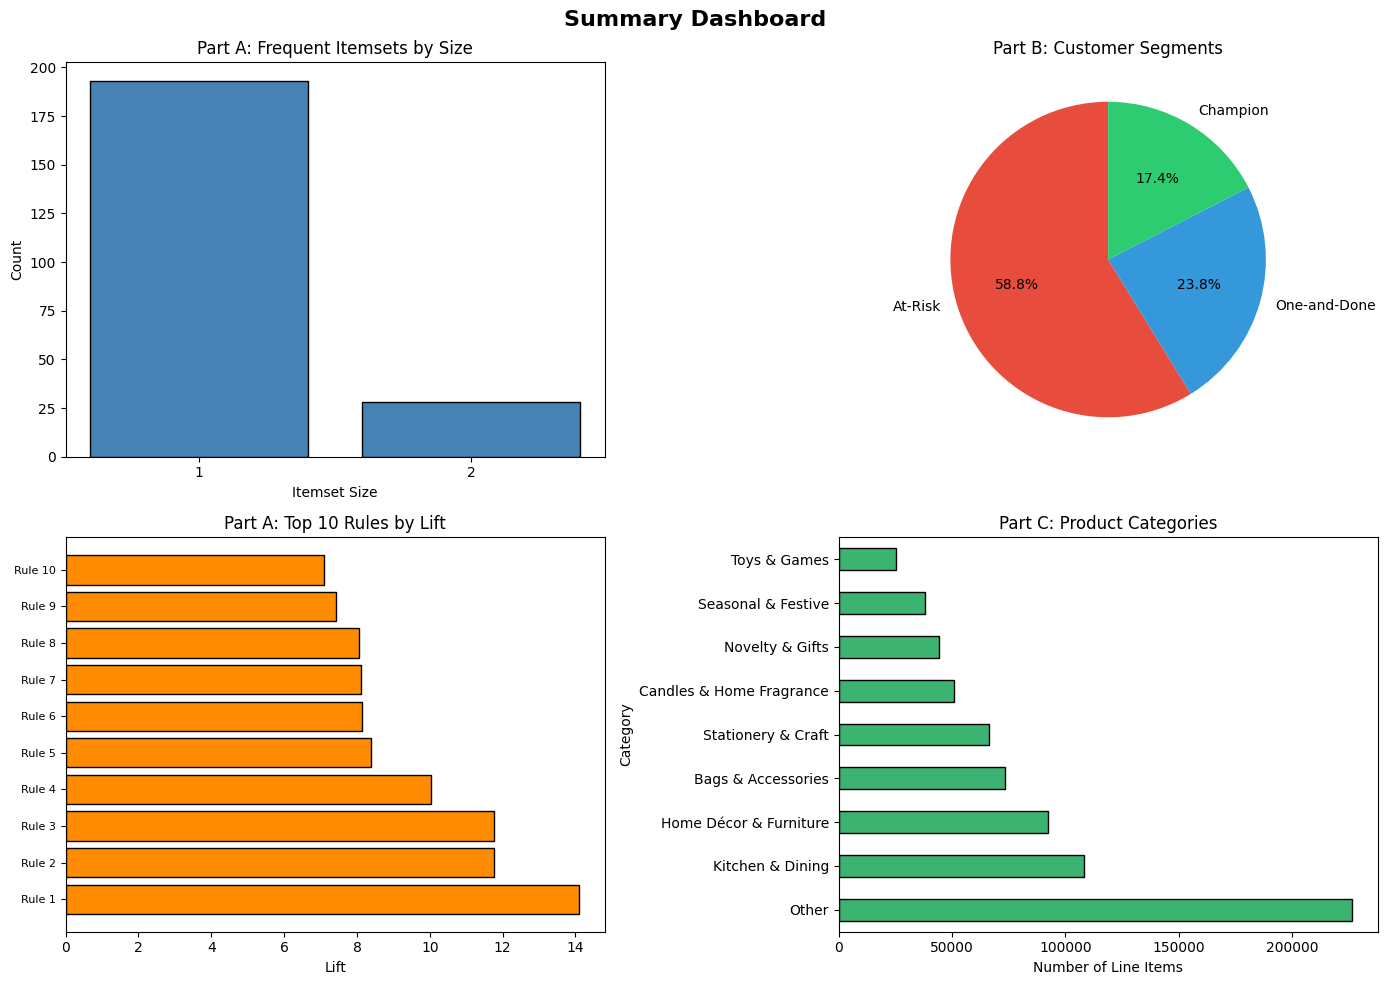

Summary dashboard saved as summary_dashboard.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Summary Dashboard', fontsize=16, fontweight='bold')


ax1 = axes[0, 0]
size_counts = frequent_itemsets.groupby('itemset_size').size()
ax1.bar(size_counts.index, size_counts.values, color='steelblue', edgecolor='black')
ax1.set_title('Part A: Frequent Itemsets by Size')
ax1.set_xlabel('Itemset Size')
ax1.set_ylabel('Count')
ax1.set_xticks(size_counts.index)


ax2 = axes[0, 1]
seg_c = rfm['Segment'].value_counts()
colors = {'Champion': '#2ecc71', 'At-Risk': '#e74c3c', 'One-and-Done': '#3498db'}
ax2.pie(seg_c.values, labels=seg_c.index,
        colors=[colors.get(s, 'gray') for s in seg_c.index],
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Part B: Customer Segments')


ax3 = axes[1, 0]
top10_lift = rules.sort_values('lift', ascending=False).head(10)
ax3.barh(range(len(top10_lift)), top10_lift['lift'].values, color='darkorange', edgecolor='black')
ax3.set_yticks(range(len(top10_lift)))
ax3.set_yticklabels([f"Rule {i+1}" for i in range(len(top10_lift))], fontsize=8)
ax3.set_title('Part A: Top 10 Rules by Lift')
ax3.set_xlabel('Lift')

ax4 = axes[1, 1]
cat_c = df['Category'].value_counts()
cat_c.plot(kind='barh', ax=ax4, color='mediumseagreen', edgecolor='black')
ax4.set_title('Part C: Product Categories')
ax4.set_xlabel('Number of Line Items')

plt.tight_layout()
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary dashboard saved as summary_dashboard.png")

In [ ]:
print("=" * 60)
print("EXPORTING RESULTS")
print("=" * 60)


if 'rules' in globals() and len(rules) > 0:

    required_cols = [
        col for col in [
            'antecedent_names',
            'consequent_names',
            'support',
            'confidence',
            'lift'
        ] if col in rules.columns
    ]

    rules.sort_values('lift', ascending=False).head(15)[required_cols] \
        .to_csv('A2_top15_rules.csv', index=False)

    print("Saved: A2_top15_rules.csv")

else:
    print("Skipped: A2_top15_rules.csv (rules not found)")


if 'rfm' in globals():

    rfm.to_csv('B_rfm_segments.csv', index=False)

    print("Saved: B_rfm_segments.csv")

else:
    print("Skipped: B_rfm_segments.csv (rfm not found)")



if 'seq_df' in globals() and len(seq_df) > 0:


    sequence_column = None

    if 'Sequence_Str' in seq_df.columns:
        sequence_column = 'Sequence_Str'
    elif 'Sequence' in seq_df.columns:
        sequence_column = 'Sequence'


    if sequence_column:

        seq_df[seq_df['Length'] == 2] \
            .sort_values(seq_df.columns[0], ascending=False) \
            .head(20)[
                [sequence_column, 'Support_Count', 'Support_Pct']
            ].to_csv('C1_top_sequences.csv', index=False)

        print("Saved: C1_top_sequences.csv")

    else:
        print("Skipped: C1_top_sequences.csv (sequence column missing)")

else:
    print("Skipped: C1_top_sequences.csv (seq_df missing)")



if 'ar_df' in globals() and len(ar_df) > 0:

    ar_df.sort_values('Count', ascending=False).head(20)[
        ['Sequence_Str', 'Count', 'Support_Pct']
    ].to_csv('C2_atrisk_patterns.csv', index=False)

    print("Saved: C2_atrisk_patterns.csv")

else:
    print("Skipped: C2_atrisk_patterns.csv (ar_df missing)")



print("\nOther generated figures:")
print("  - summary_dashboard.png")
print("  - A2a_itemset_sizes.png")
print("  - B_rfm_distributions.png")
print("  - B_segment_distribution.png")

print("\nNOTEBOOK COMPLETE! All parts executed successfully.")

EXPORTING RESULTS
Saved: A2_top15_rules.csv
Saved: B_rfm_segments.csv
Saved: C1_top_sequences.csv
Saved: C2_atrisk_patterns.csv

Other generated figures:
  - summary_dashboard.png
  - A2a_itemset_sizes.png
  - B_rfm_distributions.png
  - B_segment_distribution.png

NOTEBOOK COMPLETE! All parts executed successfully.
